## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

## Load Data

In [2]:
df = pd.read_csv('../data/raw/cs-training.csv')
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

print(f"Shape: {df.shape}")
print(f"\nTarget distribution:\n{df['SeriousDlqin2yrs'].value_counts()}")
print(f"\nDefault rate: {df['SeriousDlqin2yrs'].mean():.2%}")
df.head()

Shape: (150000, 11)

Target distribution:
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Default rate: 6.68%


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## Missing Values

In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing': missing,
    'Percentage': missing_pct
}).query('Missing > 0')

print(missing_df)

                    Missing  Percentage
MonthlyIncome         29731       19.82
NumberOfDependents     3924        2.62


## Target Distribution

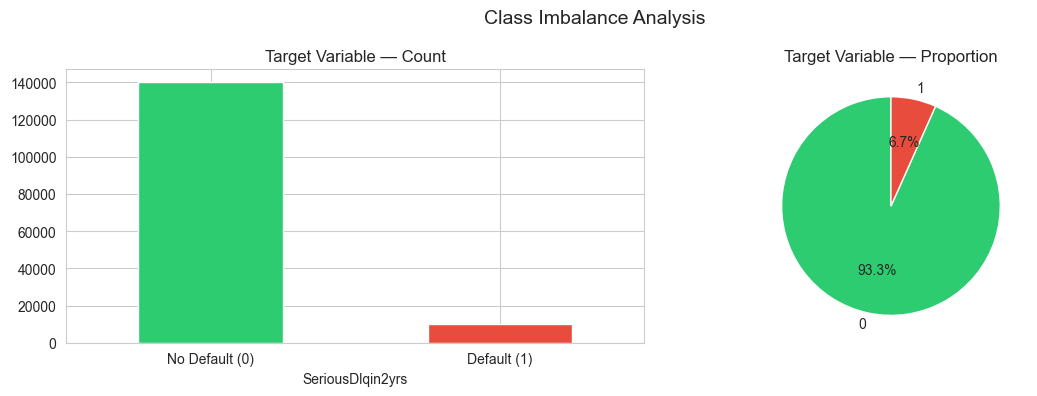

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count
df['SeriousDlqin2yrs'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#2ECC71', '#E74C3C'], edgecolor='white'
)
axes[0].set_title('Target Variable — Count')
axes[0].set_xticklabels(['No Default (0)', 'Default (1)'], rotation=0)

# Percentage
df['SeriousDlqin2yrs'].value_counts(normalize=True).plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=['#2ECC71', '#E74C3C'], startangle=90
)
axes[1].set_title('Target Variable — Proportion')
axes[1].set_ylabel('')

plt.suptitle('Class Imbalance Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/target_distribution.png', dpi=150)
plt.show()

## Feature Distributions

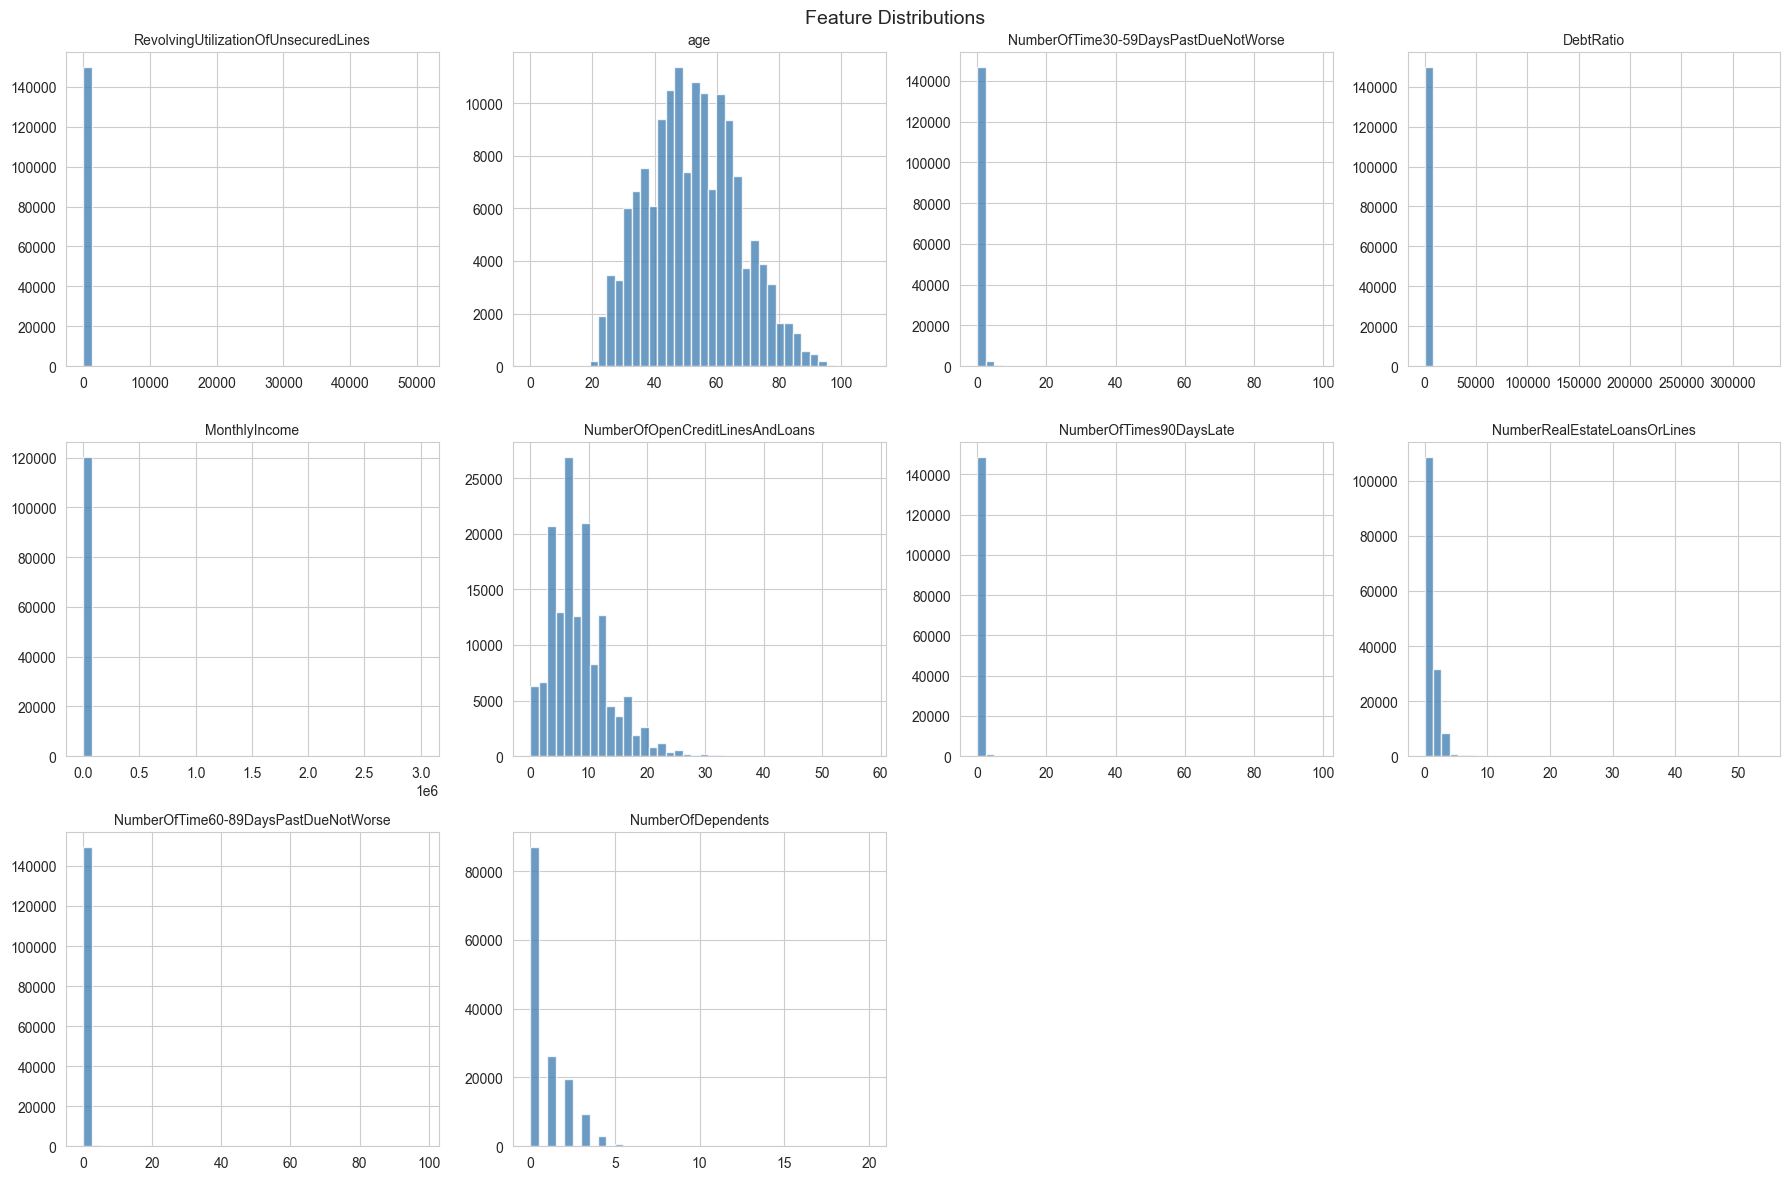

In [5]:
features = [col for col in df.columns if col != 'SeriousDlqin2yrs']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/feature_distributions.png', dpi=150)
plt.show()

## Correlation Heatmap

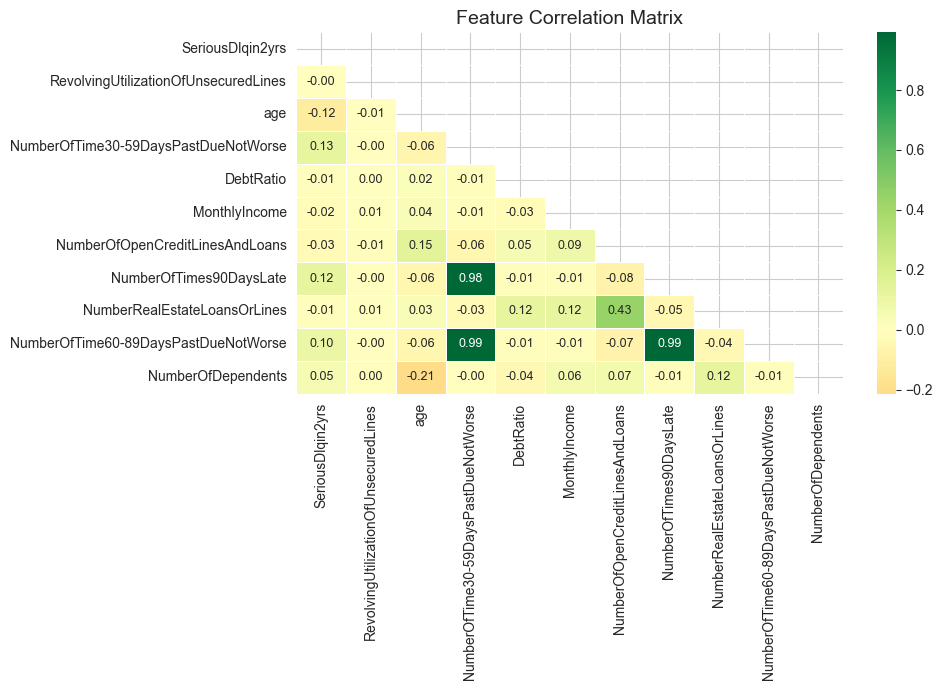

In [6]:
plt.figure(figsize=(10, 7))
corr = df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, linewidths=0.5,
    annot_kws={'size': 9}
)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/correlation_heatmap.png', dpi=150)
plt.show()

## Save clean data

In [7]:
# Fill missing values with median
df_clean = df.copy()
df_clean['MonthlyIncome'] = df_clean['MonthlyIncome'].fillna(df_clean['MonthlyIncome'].median())
df_clean['NumberOfDependents'] = df_clean['NumberOfDependents'].fillna(0)

# Remove extreme outliers
df_clean = df_clean[df_clean['age'] > 18]
df_clean = df_clean[df_clean['DebtRatio'] < 1]
df_clean = df_clean[df_clean['RevolvingUtilizationOfUnsecuredLines'] <= 1]

df_clean.to_csv('../data/processed/credit_clean.csv', index=False)
print(f"Clean dataset saved: {df_clean.shape}")
print(f"Default rate after cleaning: {df_clean['SeriousDlqin2yrs'].mean():.2%}")

Clean dataset saved: (112035, 11)
Default rate after cleaning: 6.05%
